In [1]:
import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time
import os

In [2]:
patch_size = 32
kernel_size = patch_size
image_size = 256
descriptor_dimension = 4

max_rotation = 360
rotation_multiple = 36
max_skew = 0

margin = 1.5
threshold = 0.4
learning_rate = 0.1
optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
cos_sim = tf.keras.losses.CosineSimilarity()
batch_size = 1
epochs = 100000
num_filters = 4
model_path = "filters_model.h5"
backup_model_path = "backup_filters_model.h5"

images_dir = "test/img/"
filter_file = "filters/filter_latest.npy"
images = []
for file in os.listdir(images_dir):
    if file.startswith("."):
        continue
    img = cv2.imread(os.path.join(images_dir, file))
    img = cv2.resize(img, (image_size, image_size))
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    img = img/255
    images.append(img)
    

In [3]:
centre_to_top_right = np.array([[1,0,-math.ceil(image_size/2)],
                                [0,1,-math.ceil(image_size/2)],
                                [0,0,1]])
top_right_to_centre = np.array([[1,0,math.ceil(image_size/2)],
                                [0,1,math.ceil(image_size/2)],
                                [0,0,1]])

patch_centre_to_top_right = np.array([[1,0,-math.ceil(patch_size/2)],
                                [0,1,-math.ceil(patch_size/2)],
                                [0,0,1]])
patch_top_right_to_centre = np.array([[1,0,math.ceil(patch_size//2)],
                                [0,1,math.ceil(patch_size//2)],
                                [0,0,1]])

def create_rotational_matrix(rotation, axis = "z"):
    rotation = np.radians(rotation)
    s = np.sin(rotation)
    c = np.cos(rotation)
    if axis == "z":
        return np.array([[c, -s, 0],
                          [s, c, 0],
                          [0, 0, 1]])
        
def create_skew_matrix(skew_x, skew_y):
     return np.array([[1, skew_x, 0],
                     [skew_y, 1, 0],
                     [0, 0, 1]])

In [4]:
def get_fixed_homography_matrix(val):
    rotation = rotation_multiple*val
    # rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), centre_to_top_right))
    return homography_matrix

In [5]:
def get_random_homography_matrix():
    rotation = np.random.uniform(0,max_rotation)
    # rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), centre_to_top_right))
    return homography_matrix

In [6]:
def get_gaussian_kernel(shape=(3,3), sigma=0.5):
    """build the gaussain filter"""
    m,n = [(ss-1.)/2. for ss in shape]
    x = tf.expand_dims(tf.range(-n,n+1,dtype=tf.float32),1)
    y = tf.expand_dims(tf.range(-m,m+1,dtype=tf.float32),0)
    h = tf.exp(tf.math.divide_no_nan(-((x*x) + (y*y)), 2*sigma*sigma))
    h = tf.math.divide_no_nan(h,tf.reduce_sum(h))
    h =tf.cast(h,dtype=tf.double)
    return h

def gaussian_blur(inp, shape=(3,3), sigma=0.5):
    """Convolve using tf.nn.depthwise_conv2d"""
    org_shape =tf.shape(inp)
    inp = tf.reshape(inp,( 1,*org_shape,1))
    in_channel = tf.shape(inp)[-1]
    k = get_gaussian_kernel(shape,sigma)
    k = tf.expand_dims(k,axis=-1)
    k = tf.repeat(k,in_channel,axis=-1)
    k = tf.reshape(k, (*shape, in_channel, 1))
    # using padding same to preserve size (H,W) of the input
    conv = tf.nn.depthwise_conv2d(inp, k, strides=[1,1,1,1],padding="SAME")
    conv = tf.reshape(conv,org_shape)
    return conv

def arrange_filter(filter):
    mx = np.max(filter)
    mn = np.min(filter)
    filter = filter - mn
    filter = (filter/mx)*255
    return filter

In [7]:
def get_descriptors(og, filters_batch):
    og_filter_channel = tf.repeat(og,num_filters,-1)
    og_vector = tf.reduce_mean(tf.multiply(og_filter_channel,filters_batch),[1,2])
    return og_vector

In [8]:
img = images[np.random.randint(0, len(images))]
filters = np.load(filter_file)
filters = tf.repeat(tf.reshape(tf.keras.activations.tanh(filters),(1,patch_size,patch_size,num_filters)),batch_size,0)

i = np.random.randint(0,image_size - patch_size)
j = np.random.randint(0,image_size - patch_size)
mid_i = i + (patch_size//2)
mid_j = j + (patch_size//2)
current_patch = img[i:i+patch_size, j:j+patch_size]
current_patch = cv2.blur(current_patch, (3,3))
current_patch = np.expand_dims(current_patch, axis = -1)
orig_descriptor = get_descriptors(current_patch, filters)

random_img = img #images[np.random.randint(0, len(images))]
h_m = get_random_homography_matrix()
random_img = transformed_current_patch = cv2.warpPerspective(random_img, h_m, (image_size, image_size))
check = np.zeros((image_size, image_size))
for check_i in range(0,image_size - patch_size):
    for check_j in range(0,image_size - patch_size):
        mid_check_i = check_i + (patch_size//2)
        mid_check_j = check_j + (patch_size//2)
        current_random_patch = random_img[check_i:check_i+patch_size, check_j:check_j+patch_size]
        current_random_patch = cv2.blur(current_random_patch, (3,3))
        current_random_patch = np.expand_dims(current_random_patch, axis = -1)
        check_desc = get_descriptors(current_random_patch,filters)
        prob = -cos_sim(orig_descriptor,check_desc)
        check[mid_check_i, mid_check_j] = prob
        

In [9]:
def circle_image(img, point):
    img = np.stack([img,img,img], axis=2)
    cv2.circle(img, (point[1], point[0]), 5, (0,0,255), -1)
    return img

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(187, 69)


<Axes: >

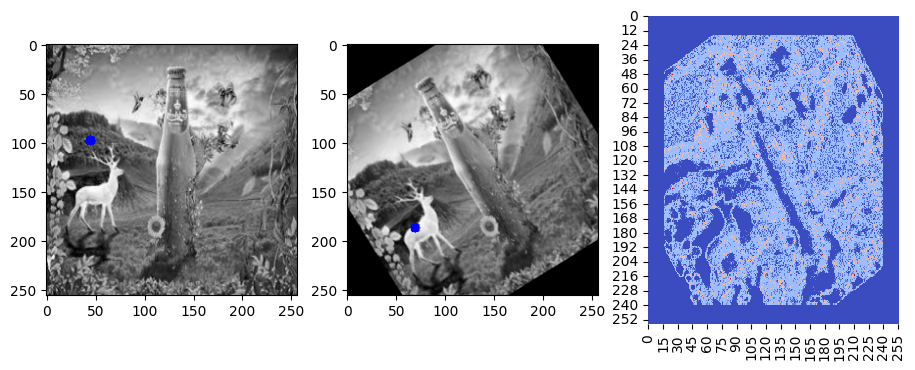

In [10]:
fig, ax = plt.subplots(ncols=3, figsize = (11, 4))
ax[0].imshow(circle_image(img, (mid_i, mid_j)))
changed_points = np.argmax(random_img)
changed_points = np.unravel_index(changed_points, random_img.shape)
print(changed_points)
ax[1].imshow((circle_image(random_img, changed_points)))
sns.heatmap(check, cbar=False, cmap = "coolwarm", vmin=0.9999999)